# 05 — Optimize TCOCNN v3 and compare it with Plain/V1

Hyperparameter optimization is part of this experiment. The final comparison focuses on validation
error, parameter count, runtime, and parameter savings. Every model receives only customer
sub-sensor 0.

Raw data source: \\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\fullData.mat
Raw input: (1090, 1, 1440, 1) ; Output acetone: (1090,)


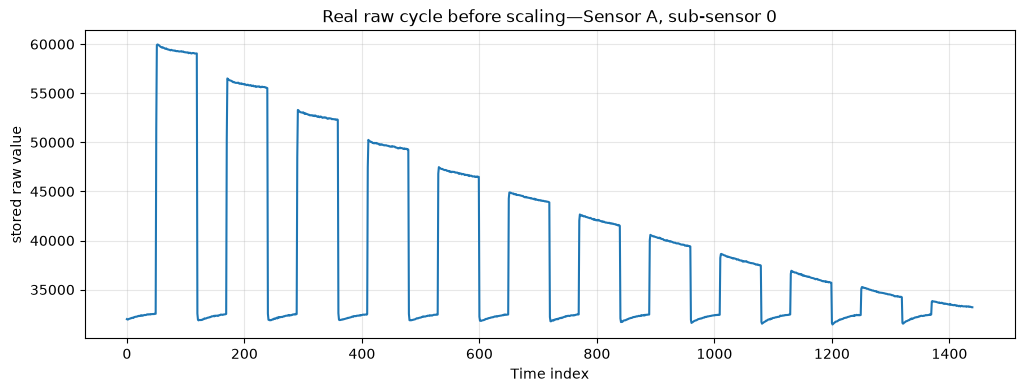

Device: cuda


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p/'Networks'/'TCOCNNv3.py').exists())
for folder in ['Networks','Evaluation Seminar/Day_02','Evaluation Seminar/Day_03','Evaluation Seminar/Day_04']:
    sys.path.insert(0,str(ROOT/folder))
import numpy as np
import matplotlib.pyplot as plt
from day3_utils import plot_comparison, regression_metrics, show_results

import torch
from skopt import Optimizer
from skopt.space import Categorical, Real
from TCOCNNv3 import TCOCNNv3Class
from day3_utils import prepare_model_data, train_experiment
splits,scaler=prepare_model_data('acetone')
print('Raw data source:',ROOT/'Data'/'fullData.mat')
print('Raw input:',splits['train']['X'].shape,'; Output acetone:',splits['train']['y'].shape)
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(splits['train']['X'][0,0,:,0])
ax.set(title='Real raw cycle before scaling—Sensor A, sub-sensor 0',xlabel='Time index',ylabel='stored raw value')
ax.grid(True,alpha=.3); plt.show()
EPOCHS=30; SEARCH_TRIALS=6; SEED=42
base=dict(n_filter=32,section_depth=3,kernel=9,stride=4,num_neurons=128,
          drop_out=.15,initial_learning_rate=5e-4,batch_size=64,
          convs_per_block=2,channel_growth=16,residual=True)
rows=[]; predictions={}; histories={}; best_v3=None; best_score=np.inf
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')


## Architecture controls

`section_depth` counts blocks and `convs_per_block` controls depth within each block. `n_filter`
sets initial width; `channel_growth` adds later channels; `stride` is the v3 pooling factor;
`residual` enables shortcuts. Parameter count, RMSE, and runtime are reported together.

In [2]:
def run_trial(label,params,v3=True):
    global best_v3,best_score
    model,metadata=train_experiment(splits,params,epochs=EPOCHS,seed=SEED,
                                    model_class=TCOCNNv3Class if v3 else None)
    prediction=model.predict(splits['val']['X_z']).ravel()*scaler['y_std']+scaler['y_mean']
    metrics=regression_metrics(splits['val']['y'],prediction)
    row={'trial':label,**metadata,**metrics,**params}; rows.append(row)
    predictions[label]=prediction; histories[label]=model.history.history
    if v3 and metrics['RMSE_ppb']<best_score:
        best_score=metrics['RMSE_ppb']; best_v3=model
    print(label,'validation RMSE:',round(metrics['RMSE_ppb'],3),flush=True)
    return metrics['RMSE_ppb']
plain={k:v for k,v in base.items() if k not in ['convs_per_block','channel_growth','residual']}
plain['num_neurons']=256
run_trial('Plain reference',plain,v3=False)
run_trial('v3 without residual',{**base,'residual':False})
run_trial('v3 with residual',base)

Epoch 1/30: train=15.3159, val=1.3291
Epoch 10/30: train=0.6828, val=0.4791
Epoch 20/30: train=0.5193, val=0.3912
Epoch 30/30: train=0.6810, val=0.4047
Plain reference validation RMSE: 26.085
Epoch 1/30: train=0.8677, val=0.5459
Epoch 10/30: train=0.5828, val=0.5800
Epoch 20/30: train=0.3494, val=0.2992
Epoch 30/30: train=0.3042, val=0.2529
v3 without residual validation RMSE: 18.596
Epoch 1/30: train=1.1605, val=0.6759
Epoch 10/30: train=0.6571, val=0.4891
Epoch 20/30: train=0.4950, val=0.5758
Epoch 30/30: train=0.4495, val=0.3117
v3 with residual validation RMSE: 23.988


23.98808119776947

In [3]:
dimensions=[Categorical([24,32,48,64],name='n_filter'),Categorical([2,3,4],name='section_depth'),
            Categorical([1,2,3],name='convs_per_block'),Categorical([0,16,32],name='channel_growth'),Categorical([5,9,15],name='kernel'),
            Categorical([2,4],name='stride'),Categorical([128,256],name='num_neurons'),
            Real(0.,.3,name='drop_out'),Real(1e-4,3e-3,prior='log-uniform',name='initial_learning_rate')]
optimizer=Optimizer(dimensions,n_initial_points=3,random_state=SEED)
for trial in range(1,SEARCH_TRIALS+1):
    values=optimizer.ask()
    sample={dimension.name:value for dimension,value in zip(dimensions,values)}
    score=run_trial(f'v3 search {trial}',{**base,**sample})
    optimizer.tell(values,score)
show_results([{k:row[k] for k in ['trial','RMSE_ppb','R2','best_epoch','parameters','seconds']} for row in rows])
show_results([{'trial':row['trial'], 'filters':row['n_filter'], 'blocks':row['section_depth'],
               'convs_per_block':row.get('convs_per_block','-'), 'channel_growth':row.get('channel_growth','-'),
               'residual':row.get('residual','-'), 'dropout':row['drop_out'],
               'kernel':row['kernel'],'pool':row['stride'],'dense':row['num_neurons'],
               'learning_rate':f"{row['initial_learning_rate']:.2e}"} for row in rows])

Epoch 1/30: train=0.8481, val=0.5941
Epoch 10/30: train=0.6662, val=0.4895
Epoch 20/30: train=0.6125, val=0.4648
Epoch 30/30: train=0.5287, val=0.4044
v3 search 1 validation RMSE: 27.754
Epoch 1/30: train=1.0070, val=0.5949
Epoch 10/30: train=0.7232, val=0.5168
Epoch 20/30: train=0.6683, val=0.4833
Epoch 30/30: train=0.5751, val=0.4485
v3 search 2 validation RMSE: 28.819
Epoch 1/30: train=0.9940, val=0.5433
Epoch 10/30: train=0.6638, val=0.4790
Epoch 20/30: train=0.5503, val=0.4333
Epoch 30/30: train=0.3709, val=0.3009
v3 search 3 validation RMSE: 23.951
Epoch 1/30: train=1.9447, val=1.1579
Epoch 10/30: train=0.7055, val=0.4980
Epoch 20/30: train=0.5636, val=0.4527
Epoch 30/30: train=0.6013, val=0.6682
v3 search 4 validation RMSE: 28.995
Epoch 1/30: train=0.8827, val=0.5619
Epoch 10/30: train=0.6881, val=0.5355
Epoch 20/30: train=0.6795, val=0.5401
Epoch 30/30: train=0.6338, val=0.4998
v3 search 5 validation RMSE: 30.479
Epoch 1/30: train=1.4704, val=0.7471
Epoch 10/30: train=0.6846, v

trial,RMSE_ppb,R2,best_epoch,parameters,seconds
Plain reference,26.085,0.549,24,2266017,14.396
v3 without residual,18.596,0.771,26,117889,9.335
v3 with residual,23.988,0.618,25,122961,12.209
v3 search 1,27.754,0.489,30,252993,19.781
v3 search 2,28.819,0.449,29,132897,12.078
v3 search 3,23.951,0.620,30,47417,6.488
v3 search 4,28.995,0.443,22,50745,9.758
v3 search 5,30.479,0.384,29,122401,16.395
v3 search 6,25.833,0.558,30,47417,10.076


trial,filters,blocks,convs_per_block,channel_growth,residual,dropout,kernel,pool,dense,learning_rate
Plain reference,32,3,-,-,-,0.150,9,4,256,5.00e-04
v3 without residual,32,3,2,16,False,0.150,9,4,128,5.00e-04
v3 with residual,32,3,2,16,True,0.150,9,4,128,5.00e-04
v3 search 1,64,2,3,16,True,0.100,9,2,128,1.63e-04
v3 search 2,48,2,3,32,True,0.183,5,4,256,1.02e-04
v3 search 3,24,3,2,0,True,0.186,15,2,128,3.67e-04
v3 search 4,24,3,2,0,True,0.000,15,4,256,3.00e-03
v3 search 5,48,2,3,32,True,0.000,5,2,128,1.00e-04
v3 search 6,24,3,2,0,True,0.241,15,4,128,3.35e-04


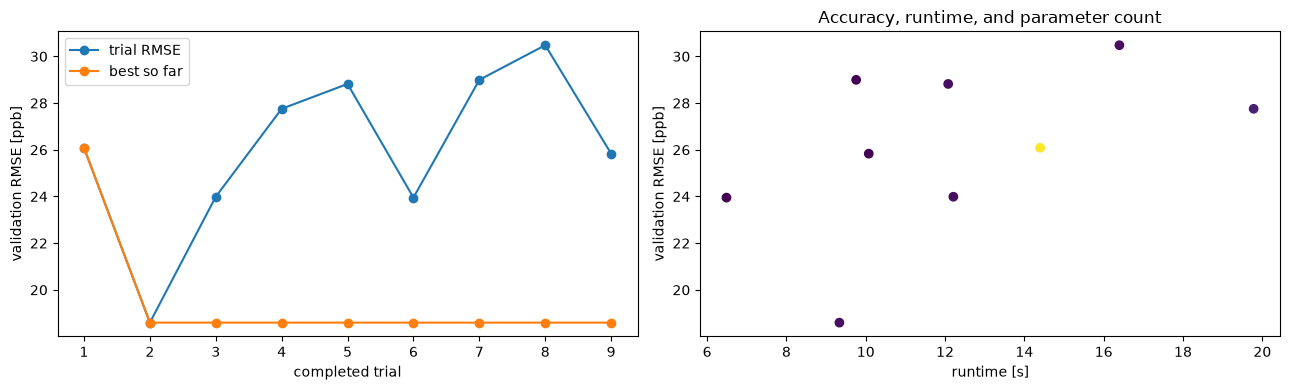

In [4]:
trial_numbers = np.arange(1, len(rows) + 1)
trial_rmse = [row["RMSE_ppb"] for row in rows]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(trial_numbers, trial_rmse, marker="o", label="trial RMSE")
axes[0].plot(
    trial_numbers,
    np.minimum.accumulate(trial_rmse),
    marker="o",
    label="best so far",
)
axes[0].set(xlabel="completed trial", ylabel="validation RMSE [ppb]")
axes[0].legend()
axes[1].scatter(
    [row["seconds"] for row in rows],
    trial_rmse,
    c=[row["parameters"] for row in rows],
    cmap="viridis",
)
axes[1].set(xlabel="runtime [s]", ylabel="validation RMSE [ppb]")
axes[1].set_title("Accuracy, runtime, and parameter count")
fig.tight_layout()

## Validation comparisons

Compare the controlled residual pair before interpreting the search winner. Common plot limits show
calibration bias. Six Bayesian trials are an executable instructional budget, not evidence that one
architecture is universally best.

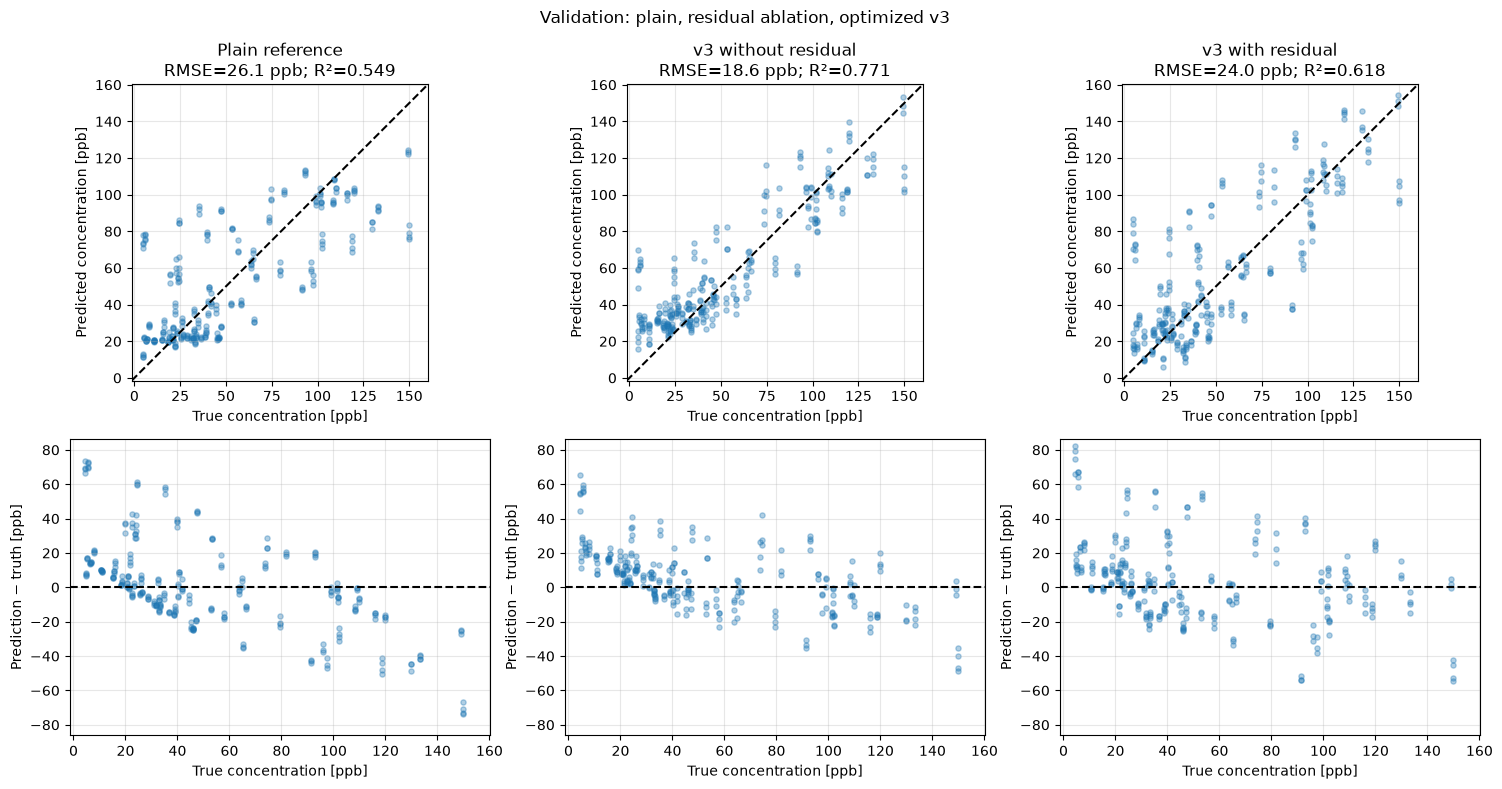

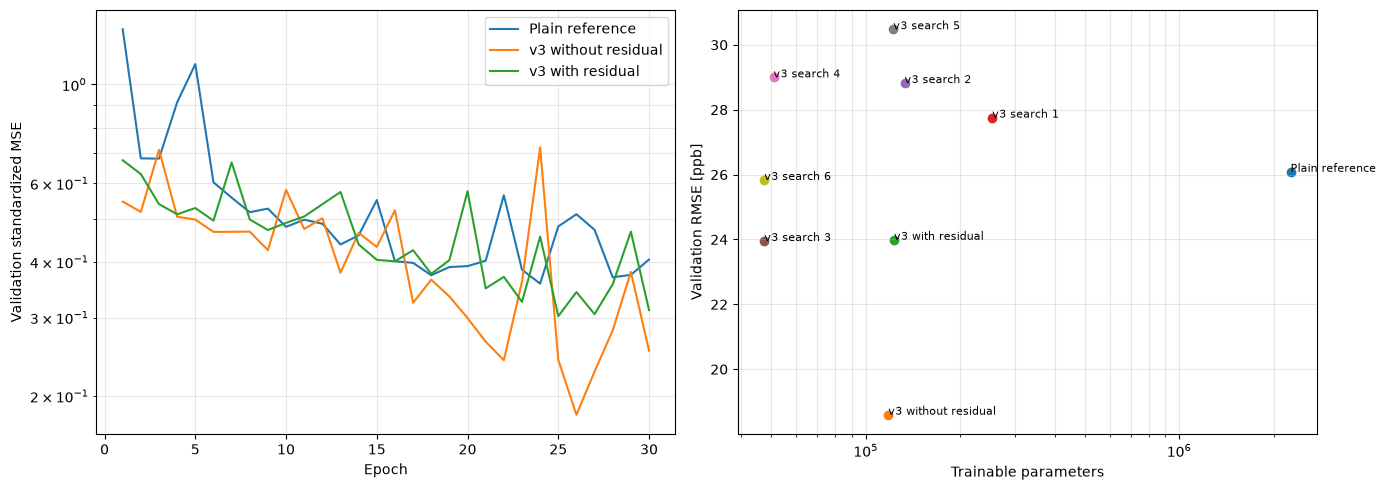

Comparison,Parameters,RMSE_ppb,saved_parameterss,savings_percent
Plain/V1 TCOCNN,2266017,26.085,0,0.000
best TCOCNN v3,117889,18.596,2148128,94.798


Best v3 saves 2,148,128 Parameters = 94.8% versus Plain/V1.


In [5]:
best_label=min((row for row in rows if row['trial']!='Plain reference'),key=lambda row:row['RMSE_ppb'])['trial']
labels=list(dict.fromkeys(['Plain reference','v3 without residual','v3 with residual',best_label]))
plot_comparison(splits['val']['y'],{label:predictions[label] for label in labels},'Validation: plain, residual ablation, optimized v3')
fig,axes=plt.subplots(1,2,figsize=(14,5))
for label in labels:
    history=histories[label]
    axes[0].plot(np.arange(1,EPOCHS+1),history['val_loss'],label=label)
axes[0].set(xlabel='Epoch',ylabel='Validation standardized MSE',yscale='log'); axes[0].legend()
for row in rows:
    axes[1].scatter(row['parameters'],row['RMSE_ppb'])
    axes[1].annotate(row['trial'],(row['parameters'],row['RMSE_ppb']),fontsize=8)
axes[1].set(xscale='log',xlabel='Trainable parameters',ylabel='Validation RMSE [ppb]')
for ax in axes: ax.grid(True,which='both',alpha=.3)
plt.tight_layout(); plt.show()
plain_row=next(row for row in rows if row['trial']=='Plain reference')
best_row=min((row for row in rows if row['trial']!='Plain reference'),key=lambda row:row['RMSE_ppb'])
saved=plain_row['parameters']-best_row['parameters']
show_results([{'Comparison':'Plain/V1 TCOCNN','Parameters':plain_row['parameters'],'RMSE_ppb':plain_row['RMSE_ppb'],
               'saved_parameterss':0,'savings_percent':0.0},
              {'Comparison':'best TCOCNN v3','Parameters':best_row['parameters'],'RMSE_ppb':best_row['RMSE_ppb'],
               'saved_parameterss':saved,'savings_percent':100*saved/plain_row['parameters']}])
print(f"Best v3 saves {saved:,} Parameters = {100*saved/plain_row['parameters']:.1f}% versus Plain/V1.")


## Freeze the v3 winner and evaluate once

The regular and extrapolation tests have not entered the search. Report both even when extrapolation
is poor. GPU operations can vary slightly despite fixed initialization seeds.

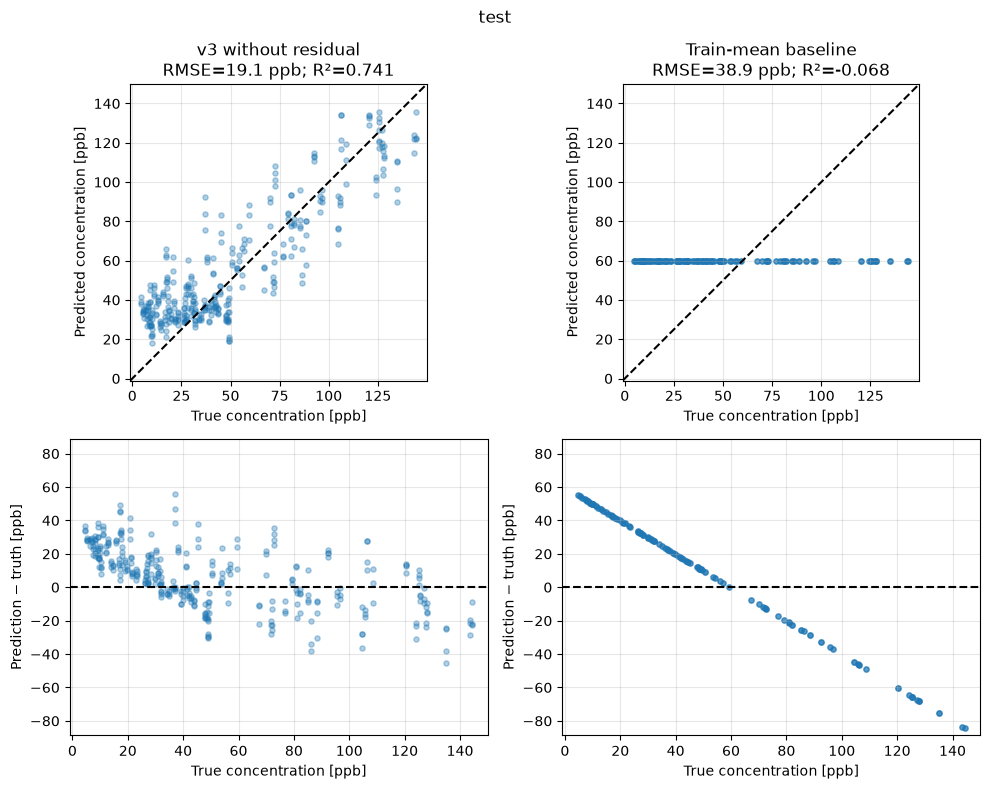

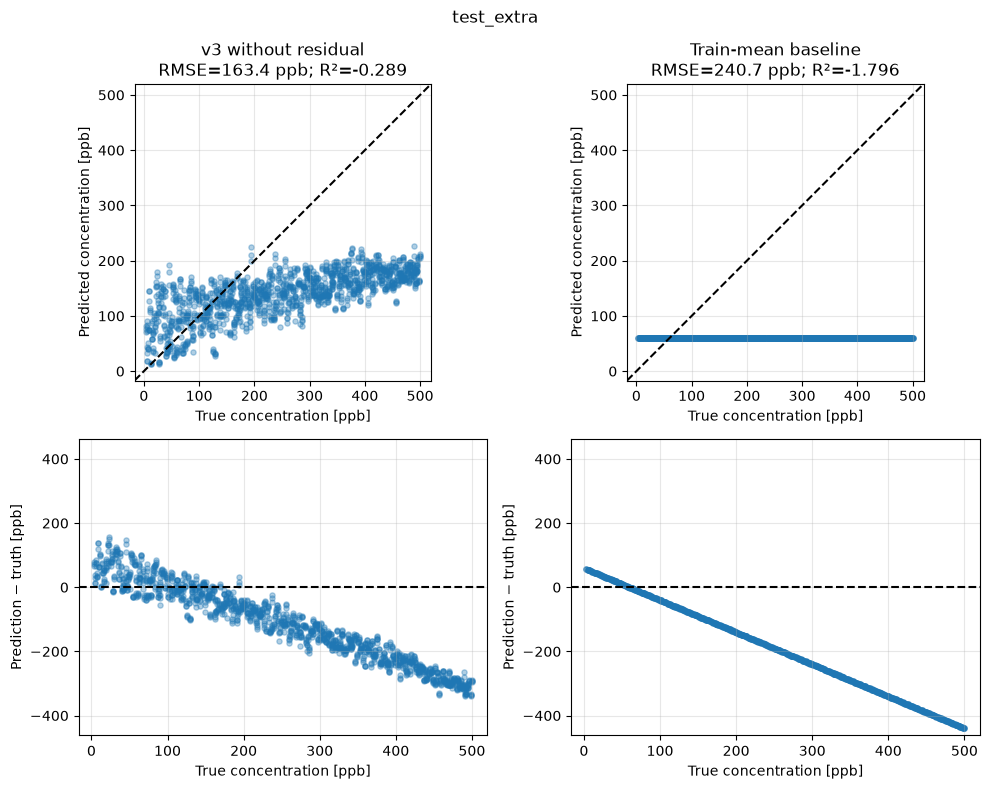

split,RMSE_ppb,MAE_ppb,R2,bias_ppb
test,19.140,15.705,0.741,6.017
test_extra,163.442,132.790,-0.289,-113.672


In [6]:
final=[]
for name in ['test','test_extra']:
    truth=splits[name]['y']
    pred=best_v3.predict(splits[name]['X_z']).ravel()*scaler['y_std']+scaler['y_mean']
    plot_comparison(truth,{best_label:pred,'Train-mean baseline':np.full_like(truth,scaler['y_mean'])},name)
    final.append({'split':name,**regression_metrics(truth,pred)})
show_results(final)
